# Comparativa d'experiments

Executa els 3 experiments × 4 models i guarda els resultats a `model_statistics/`.

| Solució | Descripció |
|---|---|
| `solucio_a` | Agent autònom amb tool calling |
| `solucio_b` | LLM parser + flux determinista (prompt bàsic) |
| `solucio_b_v2` | LLM parser + flux determinista (prompt millorat) |

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ROOT   = Path(".").resolve()
PYTHON = sys.executable
sys.path.insert(0, str(ROOT))

MODELS = [
    {"name": "phi3",             "backend": "local", "supports_tools": False},
    {"name": "llama3.2",         "backend": "local", "supports_tools": True},
    {"name": "qwen2.5:7b",       "backend": "local", "supports_tools": True},
#     {"name": "gemini-2.0-flash", "backend": "cloud", "supports_tools": True},
]

SOLUCIONS = [
    {"id": "solucio_a",    "label": "Sol. A",    "color": "#e74c3c"},
    {"id": "solucio_b",    "label": "Sol. B",    "color": "#3498db"},
    {"id": "solucio_b_v2", "label": "Sol. B v2", "color": "#2ecc71"},
]

In [2]:
def _result_path(solucio_id: str, model: str) -> Path:
    model_label = model.replace(":", "_").replace(".", "_")
    return ROOT / "model_statistics" / f"{solucio_id}_{model_label}.json"


def run_experiment(solucio_id: str, model: str, backend: str) -> dict | None:
    script = ROOT / "experiments" / f"{solucio_id}.py"
    rpath  = _result_path(solucio_id, model)

    print(f"  {solucio_id} / {model} ({backend})...", end=" ", flush=True)
    proc = subprocess.run(
        [PYTHON, str(script), "--model", model, "--backend", backend],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    if proc.returncode != 0:
        print(f"FALLAT")
        if proc.stderr:
            print(f"    {proc.stderr.strip()[-300:]}")
        if rpath.exists():
            print(f"    → carregant resultat anterior")
            return json.loads(rpath.read_text(encoding="utf-8"))
        return None

    print("OK")
    return json.loads(rpath.read_text(encoding="utf-8")) if rpath.exists() else None


def load_existing(solucio_id: str, model: str) -> dict | None:
    rpath = _result_path(solucio_id, model)
    return json.loads(rpath.read_text(encoding="utf-8")) if rpath.exists() else None

In [3]:
# Posa RUN_ALL = False per carregar els JSONs existents sense re-executar
RUN_ALL = True

# solucio_a requereix tool calling — phi3 no ho suporta
SOLS_REQUEREIXEN_TOOLS = {"solucio_a"}

resultats: dict[str, dict[str, dict]] = {}

for sol in SOLUCIONS:
    resultats[sol["id"]] = {}
    print(f"\n── {sol['id']} ──")
    for m in MODELS:
        if sol["id"] in SOLS_REQUEREIXEN_TOOLS and not m["supports_tools"]:
            print(f"  {sol['id']} / {m['name']:20s} saltat (no suporta tool calling)")
            continue
        r = run_experiment(sol["id"], m["name"], m["backend"]) if RUN_ALL \
            else load_existing(sol["id"], m["name"])
        if not RUN_ALL:
            print(f"  {sol['id']} / {m['name']:20s} {'carregat' if r else 'no disponible'}")
        if r:
            resultats[sol["id"]][m["name"]] = r

total = sum(len(v) for v in resultats.values())
n_expected = sum(
    sum(1 for m in MODELS if sol["id"] not in SOLS_REQUEREIXEN_TOOLS or m["supports_tools"])
    for sol in SOLUCIONS
)
print(f"\nTotal experiments carregats: {total} / {n_expected}")


── solucio_a ──
  solucio_a / phi3                 saltat (no suporta tool calling)
  solucio_a / llama3.2 (local)... OK
  solucio_a / qwen2.5:7b (local)... OK

── solucio_b ──
  solucio_b / phi3 (local)... OK
  solucio_b / llama3.2 (local)... OK
  solucio_b / qwen2.5:7b (local)... OK

── solucio_b_v2 ──
  solucio_b_v2 / phi3 (local)... OK
  solucio_b_v2 / llama3.2 (local)... OK
  solucio_b_v2 / qwen2.5:7b (local)... OK

Total experiments carregats: 8 / 8


In [4]:
print(f"{'Solució':<14} {'Model':<22} {'Accuracy':>10} {'JSON OK':>9} {'Extracció':>11} {'Score':>7}")
print("-" * 75)
for sol in SOLUCIONS:
    for m in MODELS:
        r = resultats[sol["id"]].get(m["name"])
        if not r:
            print(f"{sol['id']:<14} {m['name']:<22} {'—':>10} {'—':>9} {'—':>11} {'—':>7}")
            continue
        mt   = r["metriques"]
        extr = f"{mt['avg_extraccio']:.0%}" if mt.get("avg_extraccio") else "  N/A"
        print(f"{sol['id']:<14} {m['name']:<22} {mt['accuracy']:>9.0%} {mt['json_valid_rate']:>8.0%} {extr:>11}  {mt['score']:>6.3f}")

Solució        Model                    Accuracy   JSON OK   Extracció   Score
---------------------------------------------------------------------------
solucio_a      phi3                            —         —           —       —
solucio_a      llama3.2                     20%      50%         N/A   0.320
solucio_a      qwen2.5:7b                   35%      90%         N/A   0.570
solucio_b      phi3                         40%       5%         60%   0.392
solucio_b      llama3.2                     85%     100%         97%   0.917
solucio_b      qwen2.5:7b                  100%     100%         99%   0.997
solucio_b_v2   phi3                         40%       0%         57%   0.372
solucio_b_v2   llama3.2                     80%      95%        101%   0.894
solucio_b_v2   qwen2.5:7b                  100%     100%        100%   1.000


> ⚠️ **Nota metodològica — Score global**
>
> El `score` **no és directament comparable** entre la Solució A i les Solucions B/B_v2, perquè s'obté amb fórmules diferents:
> - **Sol. A** (sense extracció explícita): `accuracy × 0.6 + json_valid_rate × 0.4`
> - **Sol. B / B_v2** (amb extracció JSON): `accuracy × 0.5 + json_valid_rate × 0.2 + avg_extraccio × 0.3`
>
> La columna **Accuracy** sí que és comparable entre totes les solucions.

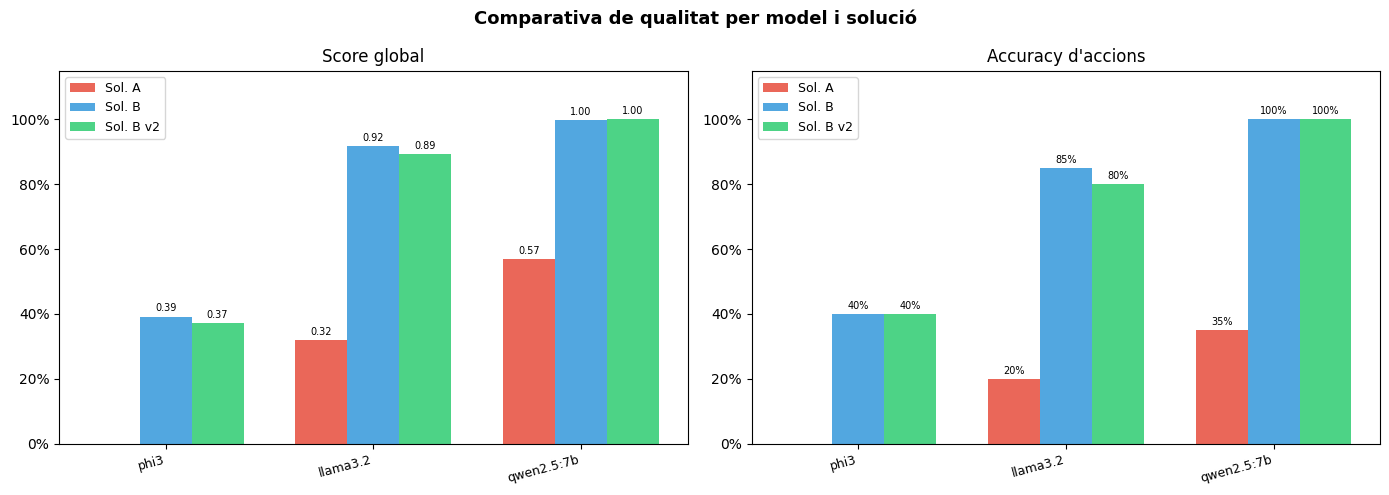

In [5]:
model_names = [m["name"] for m in MODELS]
n_models = len(model_names)
x = np.arange(n_models)
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparativa de qualitat per model i solució", fontsize=13, fontweight="bold")

for ax_idx, metric_key, title in [(0, "score", "Score global"), (1, "accuracy", "Accuracy d'accions")]:
    ax = axes[ax_idx]
    for i, sol in enumerate(SOLUCIONS):
        vals = [resultats[sol["id"]].get(m["name"], {}).get("metriques", {}).get(metric_key, 0) for m in MODELS]
        bars = ax.bar(x + i * width, vals, width, label=sol["label"], color=sol["color"], alpha=0.85)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                        f"{v:.2f}" if metric_key == "score" else f"{v:.0%}",
                        ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x + width)
    ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

plt.tight_layout()
plt.savefig(ROOT / "model_statistics" / "comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

> ⚠️ **Nota metodològica — Heatmap de scores**
>
> El color d'aquesta graella reflecteix el `score` global, que **no és comparable entre Sol. A i Sol. B/B_v2** (veure nota a dalt). Una cel·la verda de Sol. A no equival necessàriament a una cel·la verda de Sol. B.
> Per a una comparació directa, consulteu la gràfica d'**Accuracy** o la graella per correu.

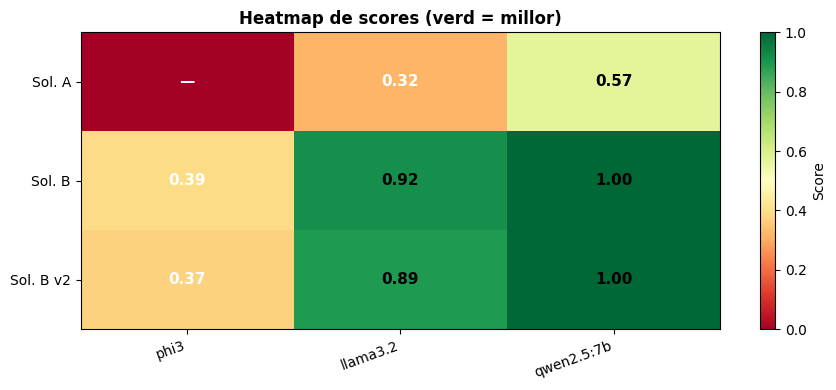

In [6]:
sol_labels = [s["label"] for s in SOLUCIONS]
n_sols     = len(SOLUCIONS)
matrix     = np.zeros((n_sols, n_models))

for i, sol in enumerate(SOLUCIONS):
    for j, m in enumerate(MODELS):
        r = resultats[sol["id"]].get(m["name"])
        if r:
            matrix[i, j] = r["metriques"]["score"]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(n_models))
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_yticks(range(n_sols))
ax.set_yticklabels(sol_labels)
ax.set_title("Heatmap de scores (verd = millor)", fontweight="bold")

for i in range(n_sols):
    for j in range(n_models):
        v = matrix[i, j]
        ax.text(j, i, f"{v:.2f}" if v > 0 else "—",
                ha="center", va="center", fontsize=11, fontweight="bold",
                color="white" if v < 0.5 else "black")

plt.colorbar(im, ax=ax, label="Score")
plt.tight_layout()
plt.savefig(ROOT / "model_statistics" / "heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

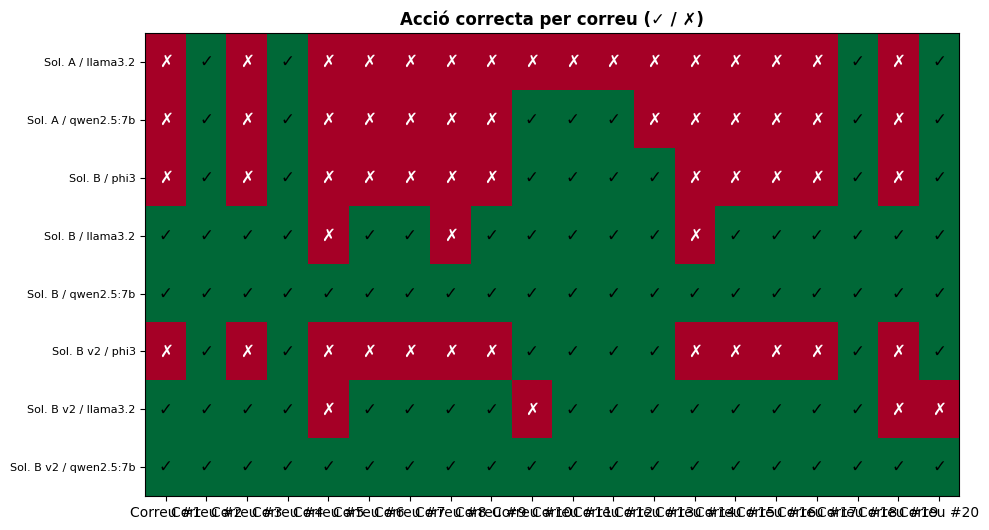

In [10]:
combis = [(sol, m) for sol in SOLUCIONS for m in MODELS if resultats[sol["id"]].get(m["name"])]
n_combis = len(combis)

mat = np.zeros((n_combis, 20))
row_labels = []
for idx, (sol, m) in enumerate(combis):
    for email in resultats[sol["id"]][m["name"]]["emails"]:
        mat[idx, email["id"] - 1] = 1 if email["accio_correcta"] else 0
    row_labels.append(f"{sol['label']} / {m['name']}")

fig, ax = plt.subplots(figsize=(10, max(3, n_combis * 0.55 + 1)))
ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(20))
ax.set_xticklabels([f"Correu #{i}" for i in range(1, 21)])
ax.set_yticks(range(n_combis))
ax.set_yticklabels(row_labels, fontsize=8)
ax.set_title("Acció correcta per correu (✓ / ✗)", fontweight="bold")

for i in range(n_combis):
    for j in range(20):
        ax.text(j, i, "✓" if mat[i, j] else "✗", ha="center", va="center",
                fontsize=12, color="white" if mat[i, j] < 0.5 else "black")

plt.tight_layout()
plt.savefig(ROOT / "model_statistics" / "per_correu.png", dpi=150, bbox_inches="tight")
plt.show()